In [1]:
#libraries import 
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
import matplotlib.pyplot as plt
import os

print("✅ Libraries loaded successfully!")
print(f"PyTorch version: {torch.__version__}")

✅ Libraries loaded successfully!
PyTorch version: 2.11.0+cpu


In [2]:
# CSV file 
df = pd.read_csv('liver_cancer_recurrence_datasetn.csv')

print(f"Dataset size: {df.shape[0]} Patients, {df.shape[1]} columns")
print(f"\nColumn නම්:\n{df.columns.tolist()}")


Dataset size: 4000 Patients, 43 columns

Column නම්:
['patient_id', 'age', 'sex', 'bmi', 'afp_level_ng_ml', 'albumin_g_dl', 'alt_u_l', 'ast_u_l', 'total_bilirubin_mg_dl', 'platelet_count_k_ul', 'prothrombin_time_sec', 'cirrhosis', 'hepatitis_b', 'hepatitis_c', 'alcohol_use', 'child_pugh_score', 'tumor_size_cm', 'tumor_count', 'vascular_invasion', 'tumor_necrosis_pct', 'satellite_nodules', 'tumor_margin', 'arterial_enhancement', 'portal_washout', 'capsule_appearance', 'liver_volume_ml', 'tumor_liver_ratio', 'texture_entropy', 'mean_intensity_hu', 'intensity_variance', 'sphericity', 'compactness', 'treatment_type', 'prior_treatment', 'resection_margin', 'nlp_risk_score', 'ner_vascular_mention', 'ner_cirrhosis_mention', 'ner_afp_high_mention', 'temporal_afp_trend', 'clinician_recurrence_concern', 'recurrence_free_survival_months', 'early_recurrence']


In [3]:
# Image  numeric columns (tumor morphology, radiomics) 
image_columns_numeric = [
    'tumor_size_cm', 'tumor_count', 'vascular_invasion', 'tumor_necrosis_pct',
    'satellite_nodules', 'arterial_enhancement', 'portal_washout',
    'texture_entropy', 'mean_intensity_hu', 'intensity_variance', 'sphericity', 'compactness'
]

# Text  numeric columns (clinical history, lab values)
text_columns_numeric = [
    'age', 'bmi', 'afp_level_ng_ml', 'albumin_g_dl', 'alt_u_l', 'ast_u_l',
    'total_bilirubin_mg_dl', 'platelet_count_k_ul', 'prothrombin_time_sec',
    'cirrhosis', 'hepatitis_b', 'hepatitis_c', 'alcohol_use'
]

#  variable
target_col = 'early_recurrence'


X_img_raw = df[image_columns_numeric].values
X_text_raw = df[text_columns_numeric].values
y = df[target_col].values

print(f"Image features shape: {X_img_raw.shape}")   
print(f"Text features shape: {X_text_raw.shape}")   
print(f"Target shape: {y.shape}")                  

Image features shape: (4000, 12)
Text features shape: (4000, 13)
Target shape: (4000,)


In [4]:
# Feature scaling (mean 0, std 1)
scaler_img = StandardScaler()
scaler_text = StandardScaler()

X_img_scaled = scaler_img.fit_transform(X_img_raw)
X_text_scaled = scaler_text.fit_transform(X_text_raw)

# Train (80%) සහ Validation (20%) 
X_img_train, X_img_val, X_text_train, X_text_val, y_train, y_val = train_test_split(
    X_img_scaled, X_text_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# PyTorch tensors 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device එක: {device}")

X_img_train = torch.tensor(X_img_train, dtype=torch.float32).to(device)
X_text_train = torch.tensor(X_text_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).to(device)

X_img_val = torch.tensor(X_img_val, dtype=torch.float32).to(device)
X_text_val = torch.tensor(X_text_val, dtype=torch.float32).to(device)
y_val = torch.tensor(y_val, dtype=torch.float32).to(device)

print(f"Train - Image: {X_img_train.shape}, Text: {X_text_train.shape}, y: {y_train.shape}")
print(f"Validation - Image: {X_img_val.shape}, Text: {X_text_val.shape}, y: {y_val.shape}")

Device එක: cpu
Train - Image: torch.Size([3200, 12]), Text: torch.Size([3200, 13]), y: torch.Size([3200])
Validation - Image: torch.Size([800, 12]), Text: torch.Size([800, 13]), y: torch.Size([800])


In [5]:
class CMFA(nn.Module):
    def __init__(self, img_in_dim=12, text_in_dim=13, proj_dim=128, num_heads=4):
        super().__init__()
        
        # Projection layers - bringing different dimensions into a single dimension
        self.img_proj = nn.Linear(img_in_dim, proj_dim)
        self.text_proj = nn.Linear(text_in_dim, proj_dim)
        
        # Cross-attention mechanism (bidirectional)
        self.cross_attn = nn.MultiheadAttention(proj_dim, num_heads, batch_first=True, dropout=0.1)
        
        # Fusion layer - merging attended features
        self.fusion = nn.Sequential(
            nn.Linear(proj_dim * 2, proj_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(proj_dim, proj_dim)
        )
        
        # Classifier head (temporary - PP1 )
        self.classifier = nn.Sequential(
            nn.Linear(proj_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
        
    def forward(self, img, text, return_attention=False):
        # Project to common dimension
        img_p = self.img_proj(img).unsqueeze(1)   # (B, 1, proj_dim)
        text_p = self.text_proj(text).unsqueeze(1) # (B, 1, proj_dim)
        
        # Bidirectional cross-attention
        img_to_text, attn_w1 = self.cross_attn(query=img_p, key=text_p, value=text_p)
        text_to_img, attn_w2 = self.cross_attn(query=text_p, key=img_p, value=img_p)
        
        # Filing together Attended features
        fused_temp = torch.cat([img_to_text.squeeze(1), text_to_img.squeeze(1)], dim=1)
        fused = self.fusion(fused_temp)   # Final fused feature vector
        
        # Recurrence probability is
        pred = self.classifier(fused)
        
        if return_attention:
            return pred.squeeze(), fused, (attn_w1, attn_w2)
        return pred.squeeze(), fused

# Model  initialise 
model = CMFA(img_in_dim=12, text_in_dim=13, proj_dim=128, num_heads=4).to(device)
print(model)

CMFA(
  (img_proj): Linear(in_features=12, out_features=128, bias=True)
  (text_proj): Linear(in_features=13, out_features=128, bias=True)
  (cross_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
  )
  (fusion): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=128, bias=True)
  )
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
    (7): Sigmoid()
  )
)


In [6]:
def train_model(model, img_train, text_train, y_train, img_val, text_val, y_val, epochs=50, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.BCELoss()
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=10, factor=0.5)
    
    train_losses = []
    val_losses = []
    val_aucs = []
    val_accs = []   # accuracy list 
    best_auc = 0
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        optimizer.zero_grad()
        preds, _ = model(img_train, text_train)
        loss = criterion(preds, y_train)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
        
        # Validation phase
        model.eval()
        with torch.no_grad():
            val_preds, _ = model(img_val, text_val)
            val_loss = criterion(val_preds, y_val).item()
            val_losses.append(val_loss)
            
            # AUC
            val_auc = roc_auc_score(y_val.cpu().numpy(), val_preds.cpu().numpy())
            val_aucs.append(val_auc)
            
            # Accuracy
            val_preds_binary = (val_preds > 0.5).float()
            val_acc = accuracy_score(y_val.cpu().numpy(), val_preds_binary.cpu().numpy())
            val_accs.append(val_acc)
            
            if val_auc > best_auc:
                best_auc = val_auc
                torch.save(model.state_dict(), 'best_cmfa_model.pth')
        
        scheduler.step(val_loss)
        
        if (epoch+1) % 5 == 0:   # Print every 5 epochs
            print(f"Epoch {epoch+1}/{epochs} | Loss: {loss.item():.4f} | Val Loss: {val_loss:.4f} | Val AUC: {val_auc:.4f} | Val Acc: {val_acc:.4f}")
    
    print(f"\n✅ Best Val AUC: {best_auc:.4f}")
    return train_losses, val_losses, val_aucs, val_accs

In [7]:
print("🚀 Training CMFA Model...")
train_losses, val_losses, val_aucs, val_accs = train_model(
    model, 
    X_img_train, X_text_train, y_train,
    X_img_val, X_text_val, y_val,
    epochs=50, lr=0.001
)

print("✅ Model saved to 'best_cmfa_model_final.pth'")

🚀 Training CMFA Model...
Epoch 5/50 | Loss: 0.6688 | Val Loss: 0.6487 | Val AUC: 0.5439 | Val Acc: 0.8425
Epoch 10/50 | Loss: 0.5431 | Val Loss: 0.4932 | Val AUC: 0.5829 | Val Acc: 0.8425
Epoch 15/50 | Loss: 0.4775 | Val Loss: 0.4655 | Val AUC: 0.6215 | Val Acc: 0.8425
Epoch 20/50 | Loss: 0.4310 | Val Loss: 0.4281 | Val AUC: 0.6241 | Val Acc: 0.8425
Epoch 25/50 | Loss: 0.4393 | Val Loss: 0.4438 | Val AUC: 0.6210 | Val Acc: 0.8425
Epoch 30/50 | Loss: 0.4246 | Val Loss: 0.4362 | Val AUC: 0.6208 | Val Acc: 0.8425
Epoch 35/50 | Loss: 0.4285 | Val Loss: 0.4352 | Val AUC: 0.6210 | Val Acc: 0.8425
Epoch 40/50 | Loss: 0.4228 | Val Loss: 0.4303 | Val AUC: 0.6186 | Val Acc: 0.8425
Epoch 45/50 | Loss: 0.4263 | Val Loss: 0.4294 | Val AUC: 0.6182 | Val Acc: 0.8425
Epoch 50/50 | Loss: 0.4268 | Val Loss: 0.4287 | Val AUC: 0.6190 | Val Acc: 0.8425

✅ Best Val AUC: 0.6268
✅ Model saved to 'best_cmfa_model_final.pth'


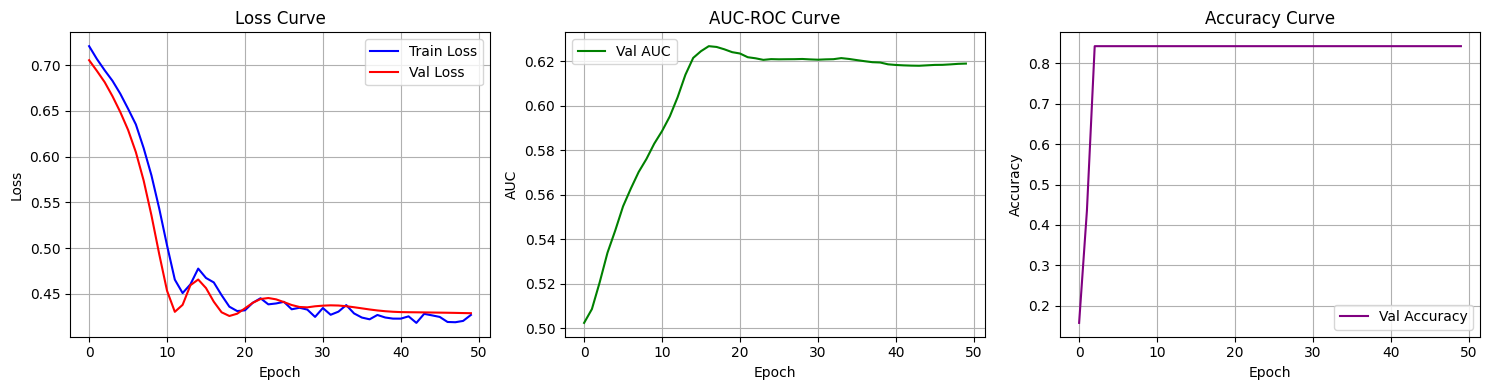

Final Validation AUC: 0.6190
Final Validation Accuracy: 0.8425


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss curve
axes[0].plot(train_losses, label='Train Loss', color='blue')
axes[0].plot(val_losses, label='Val Loss', color='red')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curve')
axes[0].legend()
axes[0].grid(True)

# AUC curve
axes[1].plot(val_aucs, label='Val AUC', color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].set_title('AUC-ROC Curve')
axes[1].legend()
axes[1].grid(True)

# Accuracy curve
axes[2].plot(val_accs, label='Val Accuracy', color='purple')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy')
axes[2].set_title('Accuracy Curve')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

print(f"Final Validation AUC: {val_aucs[-1]:.4f}")
print(f"Final Validation Accuracy: {val_accs[-1]:.4f}")

In [9]:
model.eval()
with torch.no_grad():
    val_preds, fused_features = model(X_img_val, X_text_val)
    val_preds_binary = (val_preds > 0.5).float()

accuracy = accuracy_score(y_val.cpu().numpy(), val_preds_binary.cpu().numpy())
f1 = f1_score(y_val.cpu().numpy(), val_preds_binary.cpu().numpy())
auc = roc_auc_score(y_val.cpu().numpy(), val_preds.cpu().numpy())

print("="*50)
print("📊 FINAL VALIDATION RESULTS")
print("="*50)
print(f"Accuracy:  {accuracy:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc:.4f}")
print("="*50)

print(f"\n📤 CMFA output fused features shape: {fused_features.shape}")
print("   ( Member 4  predict and explainability )")

📊 FINAL VALIDATION RESULTS
Accuracy:  0.8425
F1 Score:  0.0000
AUC-ROC:   0.6190

📤 CMFA output fused features shape: torch.Size([800, 128])
   ( Member 4  predict and explainability )


In [10]:
# Cell - Save fused features and labels for Member 4
import numpy as np

# Get fused features for entire validation set
model.eval()
with torch.no_grad():
    val_preds, fused_features = model(X_img_val, X_text_val)

# Save as .npy files
np.save('fused_features_val.npy', fused_features.cpu().numpy())
np.save('labels_val.npy', y_val.cpu().numpy())

print("✅ Fused features saved: fused_features_val.npy")
print("✅ Labels saved: labels_val.npy")
print(f"   Shape: {fused_features.shape}")

✅ Fused features saved: fused_features_val.npy
✅ Labels saved: labels_val.npy
   Shape: torch.Size([800, 128])


In [11]:
#----------------------------------------
# Cell - Loading and testing the trained model

import torch
import joblib
import numpy as np

# 1. Define the device.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# 2. Recreate the model architecture (same as training)
class CMFA(nn.Module):
    def __init__(self, img_in_dim=12, text_in_dim=13, proj_dim=128, num_heads=4):
        super().__init__()
        self.img_proj = nn.Linear(img_in_dim, proj_dim)
        self.text_proj = nn.Linear(text_in_dim, proj_dim)
        self.cross_attn = nn.MultiheadAttention(proj_dim, num_heads, batch_first=True, dropout=0.1)
        self.fusion = nn.Sequential(
            nn.Linear(proj_dim * 2, proj_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(proj_dim, proj_dim)
        )
        self.classifier = nn.Sequential(
            nn.Linear(proj_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    def forward(self, img, text, return_attention=False):
        img_p = self.img_proj(img).unsqueeze(1)
        text_p = self.text_proj(text).unsqueeze(1)
        img_to_text, attn_w1 = self.cross_attn(query=img_p, key=text_p, value=text_p)
        text_to_img, attn_w2 = self.cross_attn(query=text_p, key=img_p, value=img_p)
        fused_temp = torch.cat([img_to_text.squeeze(1), text_to_img.squeeze(1)], dim=1)
        fused = self.fusion(fused_temp)
        pred = self.classifier(fused)
        if return_attention:
            return pred.squeeze(), fused, (attn_w1, attn_w2)
        return pred.squeeze(), fused

# 3. Model instance  create 
model = CMFA(img_in_dim=12, text_in_dim=13, proj_dim=128, num_heads=4).to(device)

# 4. Saved weights load 
model.load_state_dict(torch.load('best_cmfa_model.pth', map_location=device))
model.eval()
print("✅ Model loaded successfully!")

# 5. (If necessary) Load scales (if saved in previous training)
# scaler_img = joblib.load('scaler_img.pkl')
# scaler_text = joblib.load('scaler_text.pkl')


Device: cpu
✅ Model loaded successfully!


In [12]:
import os
if os.path.exists('best_cmfa_model.pth'):
    print("Model file have!")
else:
    print("Model file not have. new train.")

Model file have!


In [13]:
#  - validation set  sample test 
with torch.no_grad():
    sample_img = X_img_val[:1]   #  validation sample 
    sample_text = X_text_val[:1]
    true_label = y_val[:1]
    
    prob, fused_feat = model(sample_img, sample_text)
    pred_class = 1 if prob.item() >= 0.5 else 0
    
    print(f"Predicted probability: {prob.item():.4f}")
    print(f"Predicted class: {pred_class}")
    print(f"True label: {true_label.item()}")
    print(f"Fused feature shape: {fused_feat.shape}")

Predicted probability: 0.1544
Predicted class: 0
True label: 0.0
Fused feature shape: torch.Size([1, 128])
